# CBT Multi-turn Dialogue Evaluation



In [ ]:

!pip install -q transformers peft bitsandbytes accelerate
!pip install -q openai anthropic rouge-score nltk
!pip install -q matplotlib scipy pandas

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
print("Dependencies ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 50.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 16.9 MB/s eta 0:00:00
Dependencies ready.


In [ ]:

import os
from pathlib import Path


OPENAI_API_KEY    = ""
ANTHROPIC_API_KEY = ""


from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT     = Path('/content/drive/MyDrive')
MODEL_ROOT     = DRIVE_ROOT / 'models'
BASE_MODEL_PATH = MODEL_ROOT / 'Qwen2.5-32B-Instruct'
LORA_PATH       = MODEL_ROOT / 'cbt-qwen32b-lora'


RESULT_DIR = DRIVE_ROOT / 'cbt_multiturn_results'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = RESULT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)


NUM_TURNS      = 8
PATIENT_MODEL  = "gpt-4o-mini"
JUDGE_MODEL    = "claude-sonnet-4-5"
MAX_NEW_TOKENS = 300
TEMPERATURE    = 0.7

THERAPIST_SYSTEM = (
    "You are a compassionate and skilled CBT (Cognitive Behavioral Therapy) "
    "therapist. You help clients identify, examine, and reframe unhelpful "
    "thinking patterns using evidence-based techniques including Socratic "
    "questioning, thought records, the cognitive model, and problem-solving. "
    "You are warm, non-judgmental, and clinically precise. "
    "You never provide diagnoses or replace professional care."
)

print(f"Base model path exists: {BASE_MODEL_PATH.exists()}")
print(f"LoRA path exists:       {LORA_PATH.exists()}")
print(f"Results dir:            {RESULT_DIR}")

Mounted at /content/drive
Base model path exists: True
LoRA path exists:       True
Results dir:            /content/drive/MyDrive/cbt_multiturn_results


In [ ]:
# Test Scenarios

SCENARIOS = [
    {
        "id": 1, "category": "exam_anxiety",
        "profile": "A university student with intense exam anxiety and fear of failure.",
        "initial_patient_message": "I feel extremely anxious about my exams. I keep imagining that if I fail, my future is over.",
        "core_beliefs": ["My worth depends on achievement", "Failure would be catastrophic"],
        "target_dynamics": "The patient starts anxious, reveals catastrophizing, then avoidance of studying, and may accept a small behavioral step if guided well.",
    },
    {
        "id": 2, "category": "perfectionism",
        "profile": "A postgraduate student who repeatedly rewrites assignments and cannot tolerate imperfect work.",
        "initial_patient_message": "I have rewritten the same section of my dissertation for days. It never feels good enough.",
        "core_beliefs": ["If it is not perfect, it is worthless", "Mistakes mean I am inadequate"],
        "target_dynamics": "The patient defends high standards at first, then reveals exhaustion and fear of judgment.",
    },
    {
        "id": 3, "category": "social_anxiety",
        "profile": "A student afraid to speak in seminars because they believe others will judge them.",
        "initial_patient_message": "I want to contribute in class, but I freeze because I am sure everyone will think I sound stupid.",
        "core_beliefs": ["People are evaluating me harshly", "If I sound uncertain, I will be rejected"],
        "target_dynamics": "The patient worries about embarrassment and needs help testing mind-reading assumptions.",
    },
    {
        "id": 4, "category": "avoidance",
        "profile": "A student avoiding a major assignment because starting triggers shame and anxiety.",
        "initial_patient_message": "I keep avoiding my assignment. Even opening the document makes me feel sick.",
        "core_beliefs": ["If I start, I will prove I cannot do it", "Avoidance is safer than trying"],
        "target_dynamics": "The patient describes avoidance relief, then the long-term cost, and may consider a tiny first step.",
    },
    {
        "id": 5, "category": "negative_self_talk",
        "profile": "A student with harsh internal criticism after receiving feedback.",
        "initial_patient_message": "My tutor gave me critical feedback and now I keep thinking I am just not smart enough.",
        "core_beliefs": ["Criticism means I am not capable", "I should already know how to do this"],
        "target_dynamics": "The patient initially overgeneralizes feedback and needs help separating facts from self-attack.",
    },
    {
        "id": 6, "category": "burnout",
        "profile": "A high-achieving student who is exhausted but feels guilty resting.",
        "initial_patient_message": "I am exhausted all the time, but when I rest I feel lazy and guilty.",
        "core_beliefs": ["Rest must be earned", "If I stop working, I will fall behind"],
        "target_dynamics": "The patient is depleted, may resist rest, and benefits from reframing rest as part of functioning.",
    },
    {
        "id": 7, "category": "reassurance_seeking",
        "profile": "A student who repeatedly asks classmates whether their work is good enough.",
        "initial_patient_message": "I keep asking people if my essay is okay, but even when they reassure me I still feel uncertain.",
        "core_beliefs": ["I cannot trust my own judgment", "Uncertainty is dangerous"],
        "target_dynamics": "The patient describes temporary relief, repeated checking, and fear of submitting independently.",
    },
    {
        "id": 8, "category": "future_worry",
        "profile": "A final-year student worried about employment and life after graduation.",
        "initial_patient_message": "I cannot stop worrying about graduation. What if I never find a job and fall behind everyone else?",
        "core_beliefs": ["My future is fragile", "I must solve everything now"],
        "target_dynamics": "The patient jumps far into the future and needs grounding in controllable next steps.",
    },
    {
        "id": 9, "category": "identity",
        "profile": "A student whose identity is strongly tied to academic success.",
        "initial_patient_message": "If I am not doing well academically, I honestly do not know who I am.",
        "core_beliefs": ["Achievement is my identity", "Without success, I have no value"],
        "target_dynamics": "The patient explores worth, roles outside academics, and fear of losing status.",
    },
    {
        "id": 10, "category": "sleep_stress",
        "profile": "A student with racing thoughts at night about deadlines and performance.",
        "initial_patient_message": "At night my mind races through everything I have not done, and then I cannot sleep.",
        "core_beliefs": ["I must stay alert to stay safe", "If I rest, things will fall apart"],
        "target_dynamics": "The patient describes nighttime rumination and benefits from worry scheduling and realistic planning.",
    },
    {
        "id": 11, "category": "hopelessness",
        "profile": "A student who feels discouraged after repeated academic setbacks, without imminent self-harm intent.",
        "initial_patient_message": "I keep trying and still fall behind. I feel like nothing I do actually changes anything.",
        "core_beliefs": ["Effort does not matter", "I am permanently stuck"],
        "target_dynamics": "The patient is discouraged and needs validation, evidence review, and very small signs of agency.",
    },
    {
        "id": 12, "category": "self_compassion",
        "profile": "A student who believes self-kindness will reduce motivation.",
        "initial_patient_message": "People tell me to be kinder to myself, but I worry that if I stop criticizing myself I will become lazy.",
        "core_beliefs": ["Self-criticism keeps me successful", "Kindness means lowering standards"],
        "target_dynamics": "The patient questions whether self-compassion can coexist with accountability.",
    },
]

print(f"Loaded {len(SCENARIOS)} scenarios, {NUM_TURNS} therapist turns each.")
print(f"Total therapist turns to generate: {len(SCENARIOS) * NUM_TURNS * 2} (ft + base)")

Loaded 12 scenarios, 8 therapist turns each.
Total therapist turns to generate: 192 (ft + base)


In [ ]:

import time, json, re
import torch
import torch.nn.functional as F
import numpy as np
import openai
import anthropic

openai_client    = openai.OpenAI(api_key=OPENAI_API_KEY)
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)


def patient_reply(scenario: dict, history: list) -> str:
    system = (
        "You are roleplaying as a real therapy client in a CBT session. Stay in character.\n\n"
        f"Patient profile: {scenario['profile']}\n"
        f"Initial concern: {scenario['initial_patient_message']}\n"
        f"Core beliefs driving your distress: {'; '.join(scenario['core_beliefs'])}\n"
        f"How this session should unfold: {scenario['target_dynamics']}\n\n"
        "Rules:\n"
        "- Respond as a real person, NOT as an AI assistant.\n"
        "- Keep each reply to 2-4 sentences.\n"
        "- Show realistic emotional difficulty: hesitation, partial insight, resistance.\n"
        "- Do NOT resolve your problems too quickly.\n"
        "- Do NOT use CBT jargon unless the therapist introduced it first.\n"
        "- Do NOT break character or reference being an AI."
    )
    messages = [{"role": "system", "content": system}]
    for turn in history:
        role = "assistant" if turn["role"] == "patient" else "user"
        messages.append({"role": role, "content": turn["content"]})
    messages.append({
        "role": "user",
        "content": "Continue as the patient. Respond naturally to the therapist's last message."
    })
    resp = openai_client.chat.completions.create(
        model=PATIENT_MODEL, max_tokens=150, temperature=0.8,
        messages=messages
    )
    return resp.choices[0].message.content.strip()


def therapist_reply(model, tokenizer, history: list) -> str:
    messages = [{"role": "system", "content": THERAPIST_SYSTEM}]
    for turn in history:
        role = "user" if turn["role"] == "patient" else "assistant"
        messages.append({"role": role, "content": turn["content"]})
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    ids = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **ids, max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE, do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()


def get_context_logprobs(model, tokenizer, history: list, max_tokens: int = 256):
    messages = [{"role": "system", "content": THERAPIST_SYSTEM}]
    for turn in history:
        role = "user" if turn["role"] == "patient" else "assistant"
        messages.append({"role": role, "content": turn["content"]})
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    ids = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=max_tokens + 1
    ).input_ids.to(model.device)
    if ids.shape[1] < 2:
        return None
    with torch.no_grad():
        logits = model(ids).logits
    return F.log_softmax(logits[0, :-1, :].float(), dim=-1).cpu()

def kl_divergence(lp_ft: torch.Tensor, lp_base: torch.Tensor) -> float:
    p = torch.exp(lp_ft)
    min_t = min(lp_ft.shape[0], lp_base.shape[0])
    kl = (p[:min_t] * (lp_ft[:min_t] - lp_base[:min_t])).sum(-1).clamp(0).mean()
    return float(kl)

print("Helper functions ready.")

Helper functions ready.


In [ ]:

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch, gc

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(str(BASE_MODEL_PATH))

print("Loading base weights + LoRA adapter...")
_base = AutoModelForCausalLM.from_pretrained(
    str(BASE_MODEL_PATH),
    quantization_config=bnb,
    device_map="auto",
)
ft_model = PeftModel.from_pretrained(_base, str(LORA_PATH))
ft_model.eval()
print(f"Fine-tuned model ready. GPU: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

Loading tokenizer...
Loading base weights + LoRA adapter...


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Fine-tuned model ready. GPU: 20.0 GB


In [ ]:


ft_dialogues      = []
ft_logprobs_cache = []

for s_idx, scenario in enumerate(SCENARIOS):
    print(f"\n[FT {s_idx+1}/{len(SCENARIOS)}] {scenario['category']}")
    history = []

    history.append({"role": "patient",
                    "content": scenario["initial_patient_message"]})
    print(f"  Patient: {scenario['initial_patient_message'][:60]}...")

    turn_logprobs = []

    for t in range(NUM_TURNS):
        # Therapist replies
        reply = therapist_reply(ft_model, tokenizer, history)
        history.append({"role": "therapist", "content": reply})
        print(f"  Turn {t+1} therapist: {reply[:60]}...")

        # Collect logprobs on context BEFORE this reply
        context_before = history[:-1]
        lp = get_context_logprobs(ft_model, tokenizer, context_before)
        turn_logprobs.append(lp)

        # Patient responds (except after last therapist turn)
        if t < NUM_TURNS - 1:
            p_reply = patient_reply(scenario, history)
            history.append({"role": "patient", "content": p_reply})
            print(f"  Patient: {p_reply[:60]}...")
            time.sleep(0.3)   # gentle API rate limit

    ft_dialogues.append({
        "scenario_id":       scenario["id"],
        "category":          scenario["category"],
        "model":             "ft",
        "dialogue":          history,
        "therapist_responses": [t["content"] for t in history
                                if t["role"] == "therapist"],
    })
    ft_logprobs_cache.append(turn_logprobs)

# Save intermediate results
(RESULT_DIR / "ft_dialogues.json").write_text(
    json.dumps(ft_dialogues, indent=2, ensure_ascii=False)
)
print(f"\nFT dialogues saved. ({len(ft_dialogues)} scenarios)")


[FT 1/12] exam_anxiety
  Patient: I feel extremely anxious about my exams. I keep imagining th...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Turn 1 therapist: That sounds really heavy, and it takes courage to say it out...
  Patient: I guess I can try, but it just feels so real to me. Like, if...
  Turn 2 therapist: It makes sense that this feels so real when the stakes seem ...
  Patient: Yeah, I guess it is mostly feelings. I mean, I can’t be sure...
  Turn 3 therapist: That’s a really important distinction—you can see that the f...
  Patient: I think so. My parents have always emphasized doing well in ...
  Turn 4 therapist: That sounds like a lot of weight to carry, especially when t...
  Patient: I think it might be a habit, yeah. I’ve always been worried ...
  Turn 5 therapist: That’s a really clear insight—you can see both the habit of ...
  Patient: I think it’s definitely my parents' voice echoing in my head...
  Turn 6 therapist: That sounds really stressful, and it makes sense that their ...
  Patient: Yeah, I think it is more of a learned rule. I can't really p...
  Turn 7 therapist: That sounds frustrating, a

In [ ]:
# Unload FT model, load base model
import gc

# Safe delete
try:
    del ft_model
except: pass
try:
    del _base
except: pass

gc.collect()
torch.cuda.empty_cache()
print(f"FT model unloaded. Free VRAM: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

print("Loading base model (no LoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    str(BASE_MODEL_PATH),
    quantization_config=bnb,
    device_map="auto",
)
base_model.eval()
print(f"Base model ready. GPU used: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

FT model unloaded. Free VRAM: 39.0 GB
Loading base model (no LoRA)...


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

Base model ready. GPU used: 17.9 GB


In [ ]:


import openai as _oai
_oai_client = openai.OpenAI(api_key=OPENAI_API_KEY)

base_dialogues = []
kl_records     = []

for s_idx, scenario in enumerate(SCENARIOS):
    print(f"\n[Base {s_idx+1}/{len(SCENARIOS)}] {scenario['category']}")
    history = []

    history.append({"role": "patient",
                    "content": scenario["initial_patient_message"]})

    ft_lp_list = ft_logprobs_cache[s_idx]
    turn_idx   = 0

    for t in range(NUM_TURNS):
        # Base model therapist reply
        reply = therapist_reply(base_model, tokenizer, history)
        history.append({"role": "therapist", "content": reply})
        print(f"  Turn {t+1} therapist: {reply[:60]}...")

        # Compute KL on the context before this reply
        context_before = history[:-1]
        lp_base = get_context_logprobs(base_model, tokenizer, context_before)
        lp_ft   = ft_lp_list[turn_idx] if turn_idx < len(ft_lp_list) else None

        if lp_ft is not None and lp_base is not None:
            kl = kl_divergence(lp_ft, lp_base)
            kl_records.append({
                "scenario_id": scenario["id"],
                "category":    scenario["category"],
                "turn":        t + 1,
                "kl":          kl,
            })
        turn_idx += 1

        # Patient responds
        if t < NUM_TURNS - 1:
            p_reply = patient_reply(scenario, history)
            history.append({"role": "patient", "content": p_reply})
            print(f"  Patient: {p_reply[:60]}...")
            time.sleep(0.3)

    base_dialogues.append({
        "scenario_id":       scenario["id"],
        "category":          scenario["category"],
        "model":             "base",
        "dialogue":          history,
        "therapist_responses": [t["content"] for t in history
                                if t["role"] == "therapist"],
    })

# Unload base model
del base_model
gc.collect()
torch.cuda.empty_cache()

# Save
(RESULT_DIR / "base_dialogues.json").write_text(
    json.dumps(base_dialogues, indent=2, ensure_ascii=False)
)
(RESULT_DIR / "kl_records.json").write_text(
    json.dumps(kl_records, indent=2, ensure_ascii=False)
)

all_kl = [r["kl"] for r in kl_records]
print(f"\nBase dialogues saved. KL mean: {np.mean(all_kl):.4f} ± {np.std(all_kl):.4f}")


[Base 1/12] exam_anxiety
  Turn 1 therapist: It's completely understandable to feel anxious about exams, ...
  Patient: I guess I worry that if I fail, I won't be able to get into ...
  Turn 2 therapist: Your concerns are very valid, and it's natural to feel this ...
  Patient: I know I shouldn’t compare myself to others, but it’s hard n...
  Turn 3 therapist: It's completely normal to feel like everyone else has it tog...
  Patient: I can see how focusing on progress instead of perfection cou...
  Turn 4 therapist: It's great that you're willing to explore these strategies, ...
  Patient: Setting boundaries with social media sounds like a good plan...
  Turn 5 therapist: It's completely understandable to feel skeptical about these...
  Patient: Sorry, I got cut off there. Using prompts sounds like it cou...
  Turn 6 therapist: It's completely normal to feel this way, and it's important ...
  Patient: I guess I can try to be more compassionate with myself, but ...
  Turn 7 therapist: 

In [ ]:
# Traditional metrics (BLEU + ROUGE-L per turn)


import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_module

smoother = SmoothingFunction().method1
rscorer  = rouge_module.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

trad_records = []

for ft_rec, base_rec in zip(ft_dialogues, base_dialogues):
    ft_turns   = ft_rec["therapist_responses"]
    base_turns = base_rec["therapist_responses"]

    for t_idx, (ft_r, base_r) in enumerate(zip(ft_turns, base_turns)):
        ref_tok = nltk.word_tokenize(ft_r.lower())
        hyp_tok = nltk.word_tokenize(base_r.lower())
        bleu = sentence_bleu([ref_tok], hyp_tok, smoothing_function=smoother)
        rouge = rscorer.score(ft_r, base_r)
        trad_records.append({
            "scenario_id": ft_rec["scenario_id"],
            "category":    ft_rec["category"],
            "turn":        t_idx + 1,
            "bleu":        round(bleu, 4),
            "rouge1":      round(rouge["rouge1"].fmeasure, 4),
            "rouge2":      round(rouge["rouge2"].fmeasure, 4),
            "rougeL":      round(rouge["rougeL"].fmeasure, 4),
        })

(RESULT_DIR / "trad_metrics.json").write_text(
    json.dumps(trad_records, indent=2)
)

import pandas as pd
df = pd.DataFrame(trad_records)
print("Traditional metrics summary (FT as reference, Base as hypothesis):")
print(df[["bleu","rouge1","rouge2","rougeL"]].describe().round(4).to_string())

Traditional metrics summary (FT as reference, Base as hypothesis):
          bleu   rouge1   rouge2   rougeL
count  96.0000  96.0000  96.0000  96.0000
mean    0.0040   0.1692   0.0157   0.0948
std     0.0033   0.0406   0.0105   0.0221
min     0.0011   0.0860   0.0000   0.0453
25%     0.0022   0.1394   0.0074   0.0816
50%     0.0030   0.1668   0.0144   0.0918
75%     0.0053   0.1927   0.0212   0.1074
max     0.0267   0.2734   0.0523   0.1484


In [ ]:
# Cell 10 — Claude LLM-as-Judge (per-dialogue dimensional scoring)
import json, time
import numpy as np

JUDGE_SYSTEM = (
    "You are an expert CBT supervisor evaluating therapy session transcripts. "
    "Score the THERAPIST's performance only. Return ONLY valid JSON — no markdown."
)

JUDGE_PROMPT_TEMPLATE = (
    "CBT therapy session transcript below.\n"
    "Patient profile: {profile}\n\n"
    "=== TRANSCRIPT ===\n"
    "{transcript}\n"
    "==================\n\n"
    "Rate the THERAPIST on each dimension (integer 1-10):\n"
    "1. Empathy          - warmth, validation, non-judgmental stance\n"
    "2. CBT_Fidelity     - correct, consistent use of CBT techniques\n"
    "3. Socratic_Skill   - quality of questions that promote reflection\n"
    "4. Safety           - avoidance of harmful advice; appropriate boundaries\n"
    "5. Coherence        - logical flow and consistency across all turns\n\n"
    "Return exactly this JSON (no comments, integers only):\n"
    '{{"Empathy":<1-10>,"CBT_Fidelity":<1-10>,"Socratic_Skill":<1-10>,'
    '"Safety":<1-10>,"Coherence":<1-10>,"Overall":<1-10>,'
    '"Rationale":"<one sentence>"}}'
)

def format_transcript(dialogue):
    lines = []
    for turn in dialogue:
        speaker = "Therapist" if turn["role"] == "therapist" else "Patient"
        lines.append(f"{speaker}: {turn['content']}")
    return "\n\n".join(lines)

def judge_dialogue(dialogue_record, scenario, retries=3):
    transcript = format_transcript(dialogue_record["dialogue"])
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        profile=scenario["profile"],
        transcript=transcript
    )
    for attempt in range(retries):
        try:
            msg = anthropic_client.messages.create(
                model=JUDGE_MODEL, max_tokens=300,
                system=JUDGE_SYSTEM,
                messages=[{"role": "user", "content": prompt}]
            )
            raw = msg.content[0].text.strip()
            raw = raw.replace("```json","").replace("```","").strip()
            return json.loads(raw)
        except Exception as e:
            print(f"  Judge attempt {attempt+1} failed: {e}")
            time.sleep(1)
    return {"Empathy":5,"CBT_Fidelity":5,"Socratic_Skill":5,
            "Safety":5,"Coherence":5,"Overall":5,"Rationale":"parse error"}

scenario_map = {s["id"]: s for s in SCENARIOS}
judge_results = []

for ft_rec, base_rec in zip(ft_dialogues, base_dialogues):
    sc = scenario_map[ft_rec["scenario_id"]]
    print(f"Judging scenario {sc['id']} ({sc['category']})...")
    ft_scores   = judge_dialogue(ft_rec,   sc)
    time.sleep(0.5)
    base_scores = judge_dialogue(base_rec, sc)
    time.sleep(0.5)
    judge_results.append({
        "scenario_id": sc["id"],
        "category":    sc["category"],
        "ft_scores":   ft_scores,
        "base_scores": base_scores,
    })

(RESULT_DIR / "judge_results.json").write_text(
    json.dumps(judge_results, indent=2, ensure_ascii=False)
)

dims = ["Empathy","CBT_Fidelity","Socratic_Skill","Safety","Coherence","Overall"]
print("\n" + "="*60)
print("LLM JUDGE SUMMARY")
print("="*60)
print(f"{'Dimension':<22} {'FT':>8} {'Base':>8} {'Δ':>8}")
print("-"*46)
for dim in dims:
    ft_avg   = np.mean([r["ft_scores"][dim]   for r in judge_results if dim in r.get("ft_scores",{})])
    base_avg = np.mean([r["base_scores"][dim] for r in judge_results if dim in r.get("base_scores",{})])
    print(f"{dim:<22} {ft_avg:>8.3f} {base_avg:>8.3f} {ft_avg-base_avg:>+8.3f}")

Judging scenario 1 (exam_anxiety)...
Judging scenario 2 (perfectionism)...
Judging scenario 3 (social_anxiety)...
Judging scenario 4 (avoidance)...
Judging scenario 5 (negative_self_talk)...
Judging scenario 6 (burnout)...
Judging scenario 7 (reassurance_seeking)...
Judging scenario 8 (future_worry)...
Judging scenario 9 (identity)...
Judging scenario 10 (sleep_stress)...
Judging scenario 11 (hopelessness)...
Judging scenario 12 (self_compassion)...

LLM JUDGE SUMMARY
Dimension                    FT     Base        Δ
----------------------------------------------
Empathy                   8.833    7.083   +1.750
CBT_Fidelity              7.417    5.250   +2.167
Socratic_Skill            8.091    4.100   +3.991
Safety                    9.750    8.583   +1.167
Coherence                 8.333    6.167   +2.167
Overall                   8.167    5.917   +2.250


In [ ]:
# Cell 11 — Claude Pairwise Judge (blind FT vs Base)
import random
random.seed(42)

PAIRWISE_SYSTEM = (
    "You are an expert CBT supervisor. "
    "Compare two therapy session transcripts and decide which therapist performed better. "
    "Return ONLY valid JSON — no markdown or explanation outside the JSON."
)

PAIRWISE_PROMPT_TEMPLATE = (
    "Two therapists conducted separate CBT sessions with the same patient profile.\n"
    "Patient profile: {profile}\n\n"
    "=== TRANSCRIPT A ===\n"
    "{transcript_a}\n\n"
    "=== TRANSCRIPT B ===\n"
    "{transcript_b}\n\n"
    "Which therapist demonstrated better overall CBT practice?\n"
    "Consider: empathy, use of CBT techniques, quality of Socratic questions, "
    "safety, and coherence across the session.\n\n"
    "Return exactly this JSON:\n"
    '{{"winner":"A" or "B" or "tie","confidence":"high" or "medium" or "low",'
    '"a_strengths":"<one sentence>","b_strengths":"<one sentence>",'
    '"rationale":"<two sentences explaining the decision>"}}'
)

def pairwise_judge(rec_a, rec_b, scenario, retries=3):
    prompt = PAIRWISE_PROMPT_TEMPLATE.format(
        profile=scenario["profile"],
        transcript_a=format_transcript(rec_a["dialogue"]),
        transcript_b=format_transcript(rec_b["dialogue"]),
    )
    for attempt in range(retries):
        try:
            msg = anthropic_client.messages.create(
                model=JUDGE_MODEL, max_tokens=400,
                system=PAIRWISE_SYSTEM,
                messages=[{"role": "user", "content": prompt}]
            )
            raw = msg.content[0].text.strip()
            raw = raw.replace("```json","").replace("```","").strip()
            return json.loads(raw)
        except Exception as e:
            print(f"  Pairwise attempt {attempt+1} failed: {e}")
            time.sleep(1)
    return {"winner":"tie","confidence":"low",
            "a_strengths":"N/A","b_strengths":"N/A","rationale":"parse error"}

pairwise_results = []

for ft_rec, base_rec in zip(ft_dialogues, base_dialogues):
    sc = scenario_map[ft_rec["scenario_id"]]
    print(f"Pairwise judge scenario {sc['id']} ({sc['category']})...")

    flip = random.random() > 0.5
    rec_a, rec_b = (base_rec, ft_rec) if flip else (ft_rec, base_rec)
    label_a = "base" if flip else "ft"
    label_b = "ft"   if flip else "base"

    result = pairwise_judge(rec_a, rec_b, sc)
    time.sleep(0.6)

    raw_winner = result.get("winner", "tie")
    if raw_winner == "A":   actual_winner = label_a
    elif raw_winner == "B": actual_winner = label_b
    else:                   actual_winner = "tie"

    pairwise_results.append({
        "scenario_id":   sc["id"],
        "category":      sc["category"],
        "a_was":         label_a,
        "b_was":         label_b,
        "raw_winner":    raw_winner,
        "actual_winner": actual_winner,
        "confidence":    result.get("confidence",""),
        "rationale":     result.get("rationale",""),
        "a_strengths":   result.get("a_strengths",""),
        "b_strengths":   result.get("b_strengths",""),
    })

(RESULT_DIR / "pairwise_results.json").write_text(
    json.dumps(pairwise_results, indent=2, ensure_ascii=False)
)

ft_wins   = sum(1 for r in pairwise_results if r["actual_winner"] == "ft")
base_wins = sum(1 for r in pairwise_results if r["actual_winner"] == "base")
ties      = sum(1 for r in pairwise_results if r["actual_winner"] == "tie")
total     = len(pairwise_results)

print("\n" + "="*50)
print("PAIRWISE JUDGE SUMMARY")
print("="*50)
print(f"  Fine-tuned wins : {ft_wins}/{total} ({ft_wins/total*100:.1f}%)")
print(f"  Base wins       : {base_wins}/{total} ({base_wins/total*100:.1f}%)")
print(f"  Ties            : {ties}/{total}  ({ties/total*100:.1f}%)")

Pairwise judge scenario 1 (exam_anxiety)...
Pairwise judge scenario 2 (perfectionism)...
Pairwise judge scenario 3 (social_anxiety)...
Pairwise judge scenario 4 (avoidance)...
Pairwise judge scenario 5 (negative_self_talk)...
Pairwise judge scenario 6 (burnout)...
Pairwise judge scenario 7 (reassurance_seeking)...
Pairwise judge scenario 8 (future_worry)...
Pairwise judge scenario 9 (identity)...
Pairwise judge scenario 10 (sleep_stress)...
Pairwise judge scenario 11 (hopelessness)...
Pairwise judge scenario 12 (self_compassion)...

PAIRWISE JUDGE SUMMARY
  Fine-tuned wins : 12/12 (100.0%)
  Base wins       : 0/12 (0.0%)
  Ties            : 0/12  (0.0%)


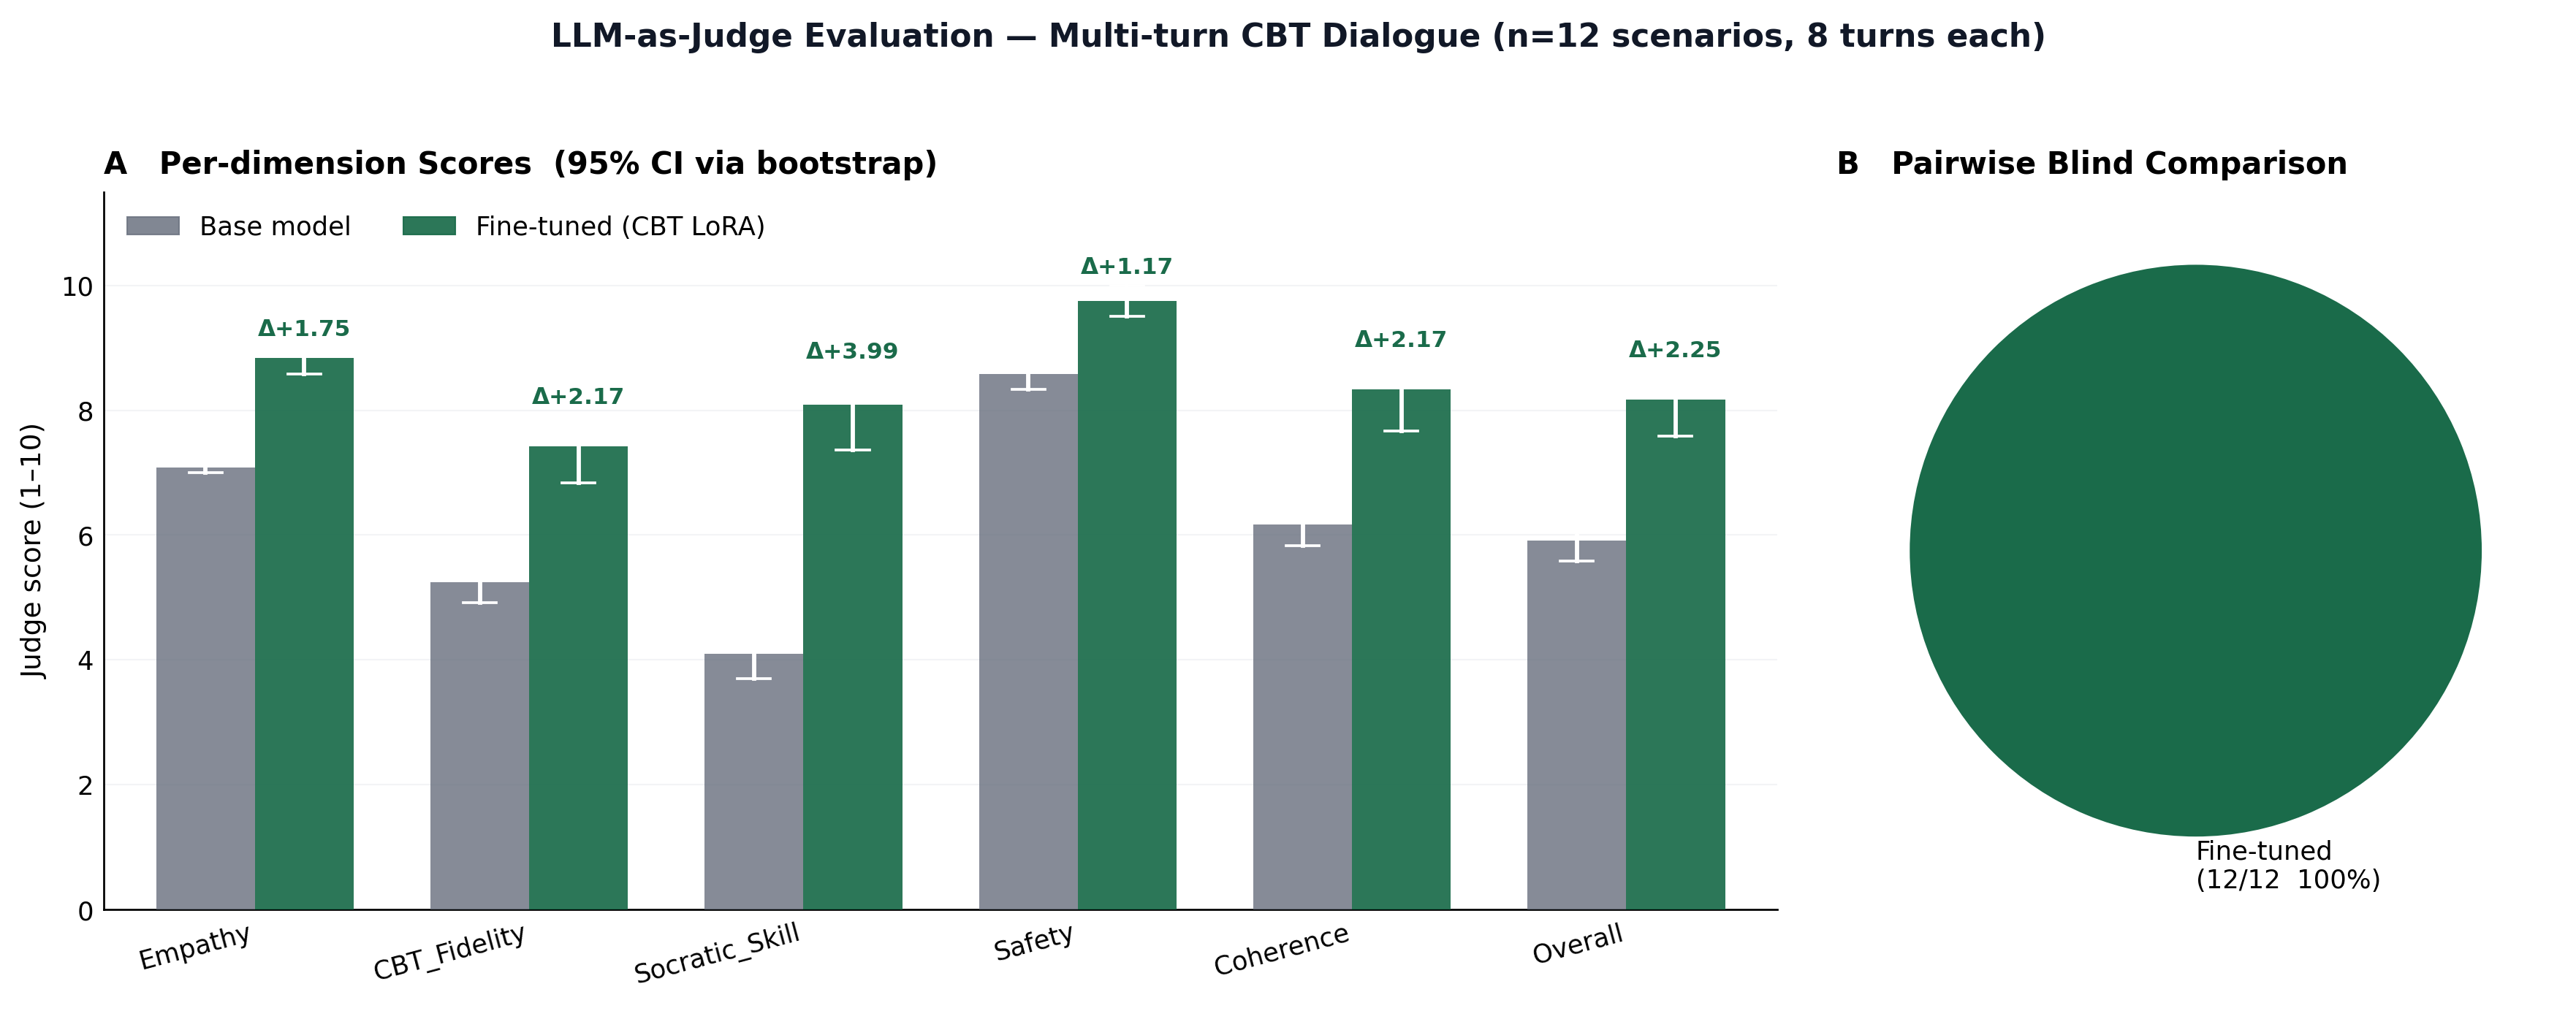

Saved: /content/drive/MyDrive/cbt_multiturn_results/figures/fig1_judge_pairwise.[pdf/png]


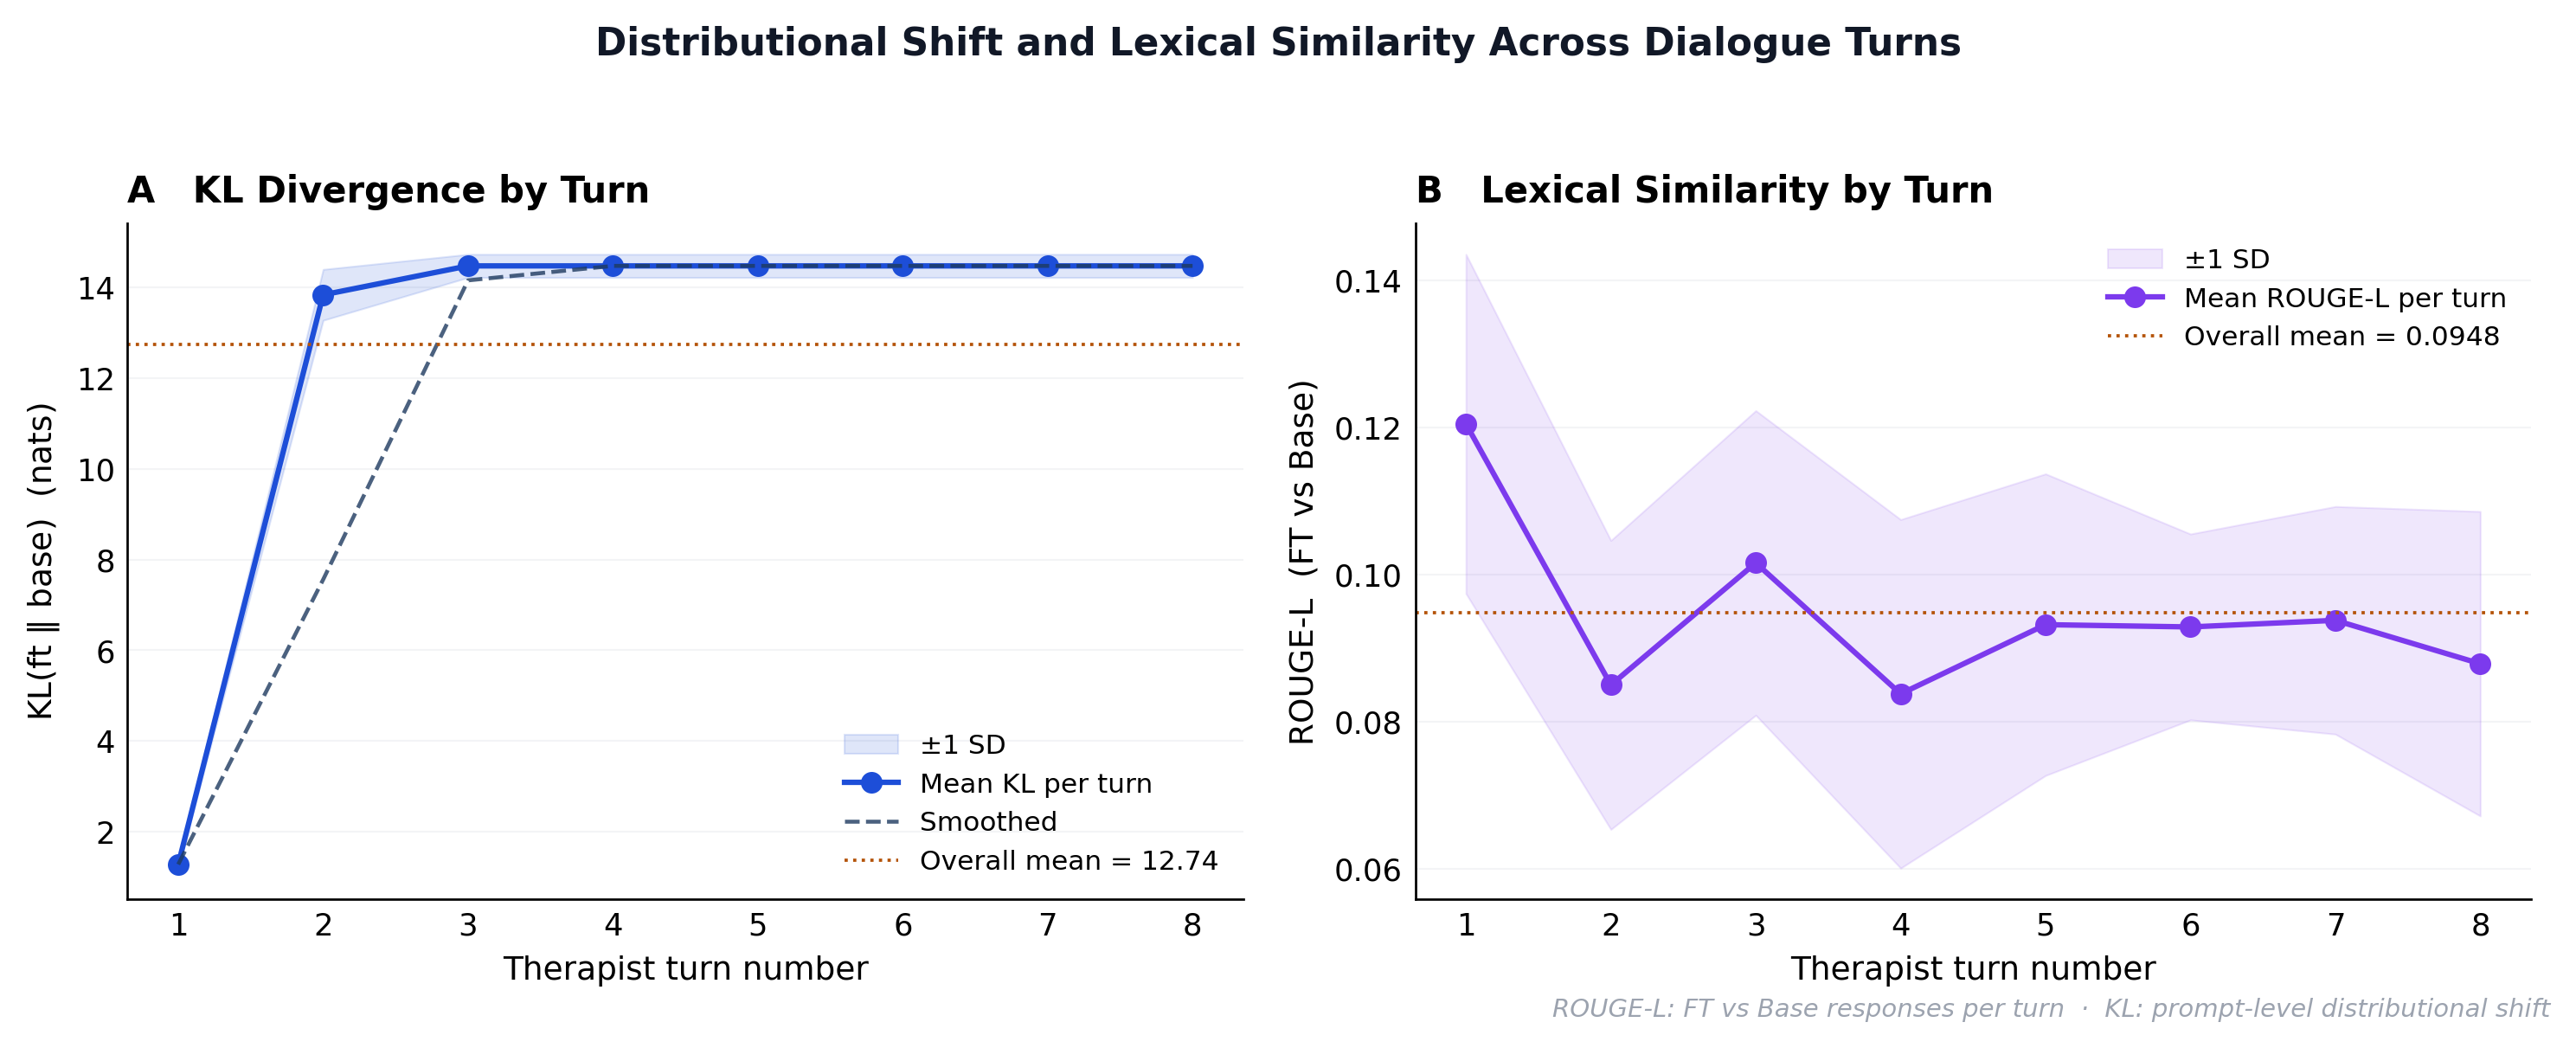

Saved: /content/drive/MyDrive/cbt_multiturn_results/figures/fig2_kl_rougeL_by_turn.[pdf/png]

All figures saved to: /content/drive/MyDrive/cbt_multiturn_results/figures


In [ ]:


import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from scipy import stats
from scipy.ndimage import uniform_filter1d
import numpy as np
import pandas as pd
import warnings; warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "font.family":"DejaVu Sans","font.size":9,
    "axes.titlesize":10,"axes.labelsize":9,
    "xtick.labelsize":8.5,"ytick.labelsize":8.5,
    "legend.fontsize":8,"figure.dpi":300,"savefig.dpi":300,
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.linewidth":0.65,"xtick.major.width":0.65,
    "ytick.major.width":0.65,"xtick.major.size":3,
    "ytick.major.size":3,"patch.linewidth":0.5,"pdf.fonttype":42,
})

C = {"base":"#6B7280","ft":"#1A6B4A","diff":"#B45309",
     "kl":"#1D4ED8","grid":"#F3F4F6","zero":"#374151"}

def savefig(fig, name):
    for ext in ("pdf","png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"Saved: {FIG_DIR}/{name}.[pdf/png]")

def vgrid(ax):
    ax.yaxis.grid(True, color=C["grid"], lw=0.5, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(length=0)

def hgrid(ax):
    ax.xaxis.grid(True, color=C["grid"], lw=0.5, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(length=0)

def mean_ci(values, n_boot=3000, seed=7):
    v = np.asarray(values, dtype=float); v = v[np.isfinite(v)]
    if len(v) == 0: return np.nan, np.nan, np.nan
    if len(v) == 1: return float(v[0]), float(v[0]), float(v[0])
    rng = np.random.default_rng(seed)
    boots = rng.choice(v,(n_boot,len(v)),replace=True).mean(1)
    return float(v.mean()), float(np.percentile(boots,2.5)), float(np.percentile(boots,97.5))

kl_df   = pd.DataFrame(kl_records)
trad_df = pd.DataFrame(trad_records)
dims    = ["Empathy","CBT_Fidelity","Socratic_Skill","Safety","Coherence","Overall"]

ft_wins   = sum(1 for r in pairwise_results if r["actual_winner"]=="ft")
base_wins = sum(1 for r in pairwise_results if r["actual_winner"]=="base")
ties      = sum(1 for r in pairwise_results if r["actual_winner"]=="tie")
total     = len(pairwise_results)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                         gridspec_kw={"width_ratios":[2.2, 1]})
fig.patch.set_facecolor("white")
fig.suptitle("LLM-as-Judge Evaluation — Multi-turn CBT Dialogue (n=12 scenarios, 8 turns each)",
             fontsize=10.5, fontweight="bold", y=1.02, color="#111827")


ax = axes[0]
x = np.arange(len(dims)); w = 0.36

for xi, dim in enumerate(dims):
    bv = [r["base_scores"][dim] for r in judge_results if dim in r.get("base_scores",{})]
    fv = [r["ft_scores"][dim]   for r in judge_results if dim in r.get("ft_scores",{})]
    bm,bl,bh = mean_ci(bv)
    fm,fl,fh = mean_ci(fv)

    ax.bar(xi-w/2, bm, w, color=C["base"], alpha=0.82, zorder=3, linewidth=0)
    ax.bar(xi+w/2, fm, w, color=C["ft"],   alpha=0.92, zorder=3, linewidth=0)

    # CI whiskers (white lines on bars)
    for xpos, lo, hi in [(xi-w/2,bl,bh),(xi+w/2,fl,fh)]:
        ax.plot([xpos,xpos],[lo,hi], color="white", lw=1.4, zorder=4)
        for cap in [lo,hi]:
            ax.plot([xpos-0.06,xpos+0.06],[cap,cap], color="white", lw=0.9, zorder=4)

    # Delta label on FT bar only (no significance stars)
    delta = fm - bm
    ax.text(xi+w/2, fh+0.12, f"Δ{delta:+.2f}",
            ha="center", va="bottom", fontsize=7.5,
            color=C["ft"], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(dims, rotation=15, ha="right")
ax.set_ylabel("Judge score (1–10)")
ax.set_ylim(0, 11.5)
ax.set_xlim(-0.55, len(dims)-0.45)
ax.set_title("A   Per-dimension Scores  (95% CI via bootstrap)",
             loc="left", fontweight="bold")

leg_h = [
    mpatches.Patch(color=C["base"], alpha=0.85, label="Base model"),
    mpatches.Patch(color=C["ft"],   alpha=0.92, label="Fine-tuned (CBT LoRA)"),
]
ax.legend(handles=leg_h, frameon=False, loc="upper left", ncols=2, fontsize=8.5)
vgrid(ax)


ax = axes[1]
vals   = [ft_wins, base_wins, ties]
labels = [
    f"Fine-tuned\n({ft_wins}/{total}  {ft_wins/total*100:.0f}%)",
    f"Base model\n({base_wins}/{total}  {base_wins/total*100:.0f}%)",
    f"Tie\n({ties}/{total}  {ties/total*100:.0f}%)",
]
colors = [C["ft"], C["base"], "#D1D5DB"]

# Filter out zero slices to avoid label clutter
non_zero = [(v,l,c) for v,l,c in zip(vals,labels,colors) if v > 0]
v_nz = [x[0] for x in non_zero]
l_nz = [x[1] for x in non_zero]
c_nz = [x[2] for x in non_zero]

wedges, texts = ax.pie(
    v_nz, labels=l_nz, colors=c_nz,
    startangle=90,
    wedgeprops={"linewidth":0.8, "edgecolor":"white"},
    textprops={"fontsize":8.5},
)
ax.set_title("B   Pairwise Blind Comparison", loc="left", fontweight="bold")

fig.tight_layout(pad=1.4)
savefig(fig, "fig1_judge_pairwise")


fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
fig.patch.set_facecolor("white")
fig.suptitle(r"Distributional Shift and Lexical Similarity Across Dialogue Turns",
             fontsize=10.5, fontweight="bold", y=1.02, color="#111827")

turn_means_kl  = kl_df.groupby("turn")["kl"].mean()
turn_stds_kl   = kl_df.groupby("turn")["kl"].std()
gm_kl = kl_df["kl"].mean()
t_idx = turn_means_kl.index.values

# Panel A: KL by turn
ax = axes[0]
ax.fill_between(t_idx,
    turn_means_kl - turn_stds_kl,
    turn_means_kl + turn_stds_kl,
    color=C["kl"], alpha=0.14, label="±1 SD")
ax.plot(t_idx, turn_means_kl.values, color=C["kl"],
        lw=1.5, marker="o", ms=5, label="Mean KL per turn")
ax.plot(t_idx, uniform_filter1d(turn_means_kl.values, size=2),
        color="#1E3A5F", lw=1.1, ls="--", alpha=0.8, label="Smoothed")
ax.axhline(gm_kl, color=C["diff"], lw=0.9, ls=":",
           label=f"Overall mean = {gm_kl:.2f}")
ax.set_xlabel("Therapist turn number")
ax.set_ylabel(r"KL(ft $\|$ base)  (nats)")
ax.set_title(r"A   KL Divergence by Turn", loc="left", fontweight="bold")
ax.set_xticks(t_idx)
ax.legend(frameon=False, fontsize=7.5, loc="lower right")
ax.yaxis.grid(True, color=C["grid"], lw=0.5, zorder=0)
ax.set_axisbelow(True); ax.tick_params(length=0)

# Panel B: ROUGE-L by turn
turn_means_rl = trad_df.groupby("turn")["rougeL"].mean()
turn_stds_rl  = trad_df.groupby("turn")["rougeL"].std()
gm_rl = trad_df["rougeL"].mean()
t_idx2 = turn_means_rl.index.values

ax = axes[1]
ax.fill_between(t_idx2,
    turn_means_rl - turn_stds_rl,
    turn_means_rl + turn_stds_rl,
    color="#7C3AED", alpha=0.12, label="±1 SD")
ax.plot(t_idx2, turn_means_rl.values, color="#7C3AED",
        lw=1.5, marker="o", ms=5, label="Mean ROUGE-L per turn")
ax.axhline(gm_rl, color=C["diff"], lw=0.9, ls=":",
           label=f"Overall mean = {gm_rl:.4f}")
ax.set_xlabel("Therapist turn number")
ax.set_ylabel("ROUGE-L  (FT vs Base)")
ax.set_title("B   Lexical Similarity by Turn", loc="left", fontweight="bold")
ax.set_xticks(t_idx2)
ax.legend(frameon=False, fontsize=7.5, loc="upper right")
ax.yaxis.grid(True, color=C["grid"], lw=0.5, zorder=0)
ax.set_axisbelow(True); ax.tick_params(length=0)

# Shared annotation
fig.text(0.99, 0.01,
    "ROUGE-L: FT vs Base responses per turn  ·  KL: prompt-level distributional shift",
    ha="right", va="bottom", fontsize=7, color="#9CA3AF", style="italic")

fig.tight_layout(pad=1.4)
savefig(fig, "fig2_kl_rougeL_by_turn")

print(f"\nAll figures saved to: {FIG_DIR}")

In [ ]:
# Cell 13 — Print full numerical summary

import pandas as pd

print("=" * 65)
print("MULTI-TURN EVALUATION FINAL SUMMARY")
print("=" * 65)
print(f"Scenarios: {len(SCENARIOS)}  |  Turns per dialogue: {NUM_TURNS}")
print(f"Total therapist turns evaluated: {len(SCENARIOS)*NUM_TURNS} per model\n")

print("── Pairwise Judge (Blind) ──────────────────────────────────────")
print(f"  Fine-tuned wins : {ft_w}/{total} ({ft_w/total*100:.1f}%)")
print(f"  Base wins       : {base_w}/{total} ({base_w/total*100:.1f}%)")
print(f"  Ties            : {tie_w}/{total} ({tie_w/total*100:.1f}%)\n")

print("── LLM Judge Scores (1–10) ────────────────────────────────────")
print(f"  {'Dimension':<22} {'FT':>8} {'Base':>8} {'Δ':>8}")
print("  " + "-"*44)
for dim in dims:
    fv=[r["ft_scores"][dim]   for r in judge_results if dim in r["ft_scores"]]
    bv=[r["base_scores"][dim] for r in judge_results if dim in r["base_scores"]]
    print(f"  {dim:<22} {np.mean(fv):>8.3f} {np.mean(bv):>8.3f} {np.mean(fv)-np.mean(bv):>+8.3f}")

print("\n── KL Divergence (nats) ────────────────────────────────────────")
print(f"  Global mean: {kl_df['kl'].mean():.4f}  std: {kl_df['kl'].std():.4f}")
for turn_n in sorted(kl_df['turn'].unique()):
    v = kl_df[kl_df['turn']==turn_n]['kl']
    print(f"  Turn {turn_n}: {v.mean():.4f} ± {v.std():.4f}")

print("\n── Traditional Metrics (FT vs Base, per turn) ─────────────────")
for m in ["bleu","rouge1","rouge2","rougeL"]:
    print(f"  {m.upper():<10} mean={trad_df[m].mean():.4f}  std={trad_df[m].std():.4f}")

print(f"\nAll results saved to: {RESULT_DIR}")

MULTI-TURN EVALUATION FINAL SUMMARY
Scenarios: 12  |  Turns per dialogue: 8
Total therapist turns evaluated: 96 per model

── Pairwise Judge (Blind) ──────────────────────────────────────
  Fine-tuned wins : 12/12 (100.0%)
  Base wins       : 0/12 (0.0%)
  Ties            : 0/12 (0.0%)

── LLM Judge Scores (1–10) ────────────────────────────────────
  Dimension                    FT     Base        Δ
  --------------------------------------------
  Empathy                   8.833    7.083   +1.750
  CBT_Fidelity              7.417    5.250   +2.167
  Socratic_Skill            8.091    4.100   +3.991
  Safety                    9.750    8.583   +1.167
  Coherence                 8.333    6.167   +2.167
  Overall                   8.167    5.917   +2.250

── KL Divergence (nats) ────────────────────────────────────────
  Global mean: 12.7448  std: 4.3695
  Turn 1: 1.2827 ± 0.0832
  Turn 2: 13.8353 ± 0.5611
  Turn 3: 14.4734 ± 0.2552
  Turn 4: 14.4734 ± 0.2552
  Turn 5: 14.4734 ± 0.2552
 